### The standard UCB1 algorithm

In [1]:
from cmab.algorithms.base import BaseBanditAlgorithm
import numpy as np
from cmab.typing import Intervention, Observation

class UCBAgent(BaseBanditAlgorithm):
    """
    Args:
    c: float, degree of exploration
    """
    def __init__(self, reward_node:str, arms: list[Intervention], c:float=np.sqrt(2)):
        super().__init__(reward_node)
        self.arms = arms
        self.n_arms = len(arms)
        self.c = c
        self.means = np.zeros(self.n_arms)
        self.arm_samples = np.zeros(self.n_arms, dtype=int)
        self.t = 0
        self.arm_to_index = {arm: idx for idx, arm in enumerate(arms)}

    def select_arm(self) -> Intervention:
        self.t += 1
        for i in range(self.n_arms):   # ensure each arm is tried once
            if self.arm_samples[i] == 0:
                return self.arms[i]

        ucb_values = []
        for arm in range(self.n_arms): 
            n_arm = self.arm_samples[arm]
            t = np.sum(self.arm_samples)  
            bound = np.sqrt(np.log(t)/n_arm)
            ucb_values.append(self.means[arm] + self.c*bound)
        return self.arms[np.argmax(ucb_values)]
    
    def _update(self, arm: Intervention, observation: Observation) -> None:
        reward = observation[self.reward_node]
        arm_index = self.arm_to_index[arm]
        self.arm_samples[arm_index] += 1
        num_samples = self.arm_samples[arm_index]
        prev_mean = self.means[arm_index]
        self.means[arm_index] = prev_mean + 1/(num_samples)*(reward - prev_mean)
    
    def reset(self):
        self.t = 0
        self.means = np.zeros(self.n_arms)
        self.arm_samples = np.zeros(self.n_arms, dtype=int)


### Standard UCB1 that resets at every 500th step for testing

In [2]:
class SegmentUCBAgent(BaseBanditAlgorithm):
    """
    Args:
    c: float, degree of exploration
    """
    def __init__(self, reward_node:str, arms: list[Intervention], c:float=np.sqrt(2)):
        super().__init__(reward_node)
        self.arms = arms
        self.n_arms = len(arms)
        self.c = c
        self.means = np.zeros(self.n_arms)
        self.arm_samples = np.zeros(self.n_arms, dtype=int)
        self.t = 0
        self.arm_to_index = {arm: idx for idx, arm in enumerate(arms)}

    def select_arm(self) -> Intervention:
        self.t += 1
        for i in range(self.n_arms):   # ensure each arm is tried once
            if self.arm_samples[i] == 0:
                return self.arms[i]

        ucb_values = []
        for arm in range(self.n_arms): 
            n_arm = self.arm_samples[arm]
            t = np.sum(self.arm_samples)  
            bound = np.sqrt(np.log(t)/n_arm)
            ucb_values.append(self.means[arm] + self.c*bound)
        return self.arms[np.argmax(ucb_values)]
    
    def _update(self, arm: Intervention, observation: Observation) -> None:
        if self.t in [500,1000,1500]:  # reset every 500 steps
            self.reset()
        reward = observation[self.reward_node]
        arm_index = self.arm_to_index[arm]
        self.arm_samples[arm_index] += 1
        num_samples = self.arm_samples[arm_index]
        prev_mean = self.means[arm_index]
        self.means[arm_index] = prev_mean + 1/(num_samples)*(reward - prev_mean)
    
    def reset(self):
        self.t = 0
        self.means = np.zeros(self.n_arms)
        self.arm_samples = np.zeros(self.n_arms, dtype=int)


### Building an environment with X -> Y, Z -> Y

In [4]:
from benchmarking.plotting import  plot_regrets_and_change_points, plot_reset_rate_heatmap, plot_historical_means
from cmab.utils.utils import compute_means_history
from cmab.metrics.dynamic_regret import DynamicRegret
from cmab.typing import Intervention
import numpy as np
from pathlib import Path
from benchmarking.environments import build_environment
from cmab.environments.ns.scheduling.controlled_schedule import ControlledShiftSchedule, ControlledMechanismChangeSchedule
from cmab.environments.ns.scheduling.stationary_schedule import StationarySchedule

seed = 42
c=np.sqrt(2)

schedule = ControlledShiftSchedule(
    variables=["U_Y", "U_Y", "U_Y"],
    new_params=[0.1, 0.9, 0.1],
    every=500
)

env_params = {
    "environment": "markovian",
    "reward_node": "Y",
    "atomic": True,
    "include_empty": False,
    "p_x": 0.1,
    "p_z": 0.7,
    "p_y": 0.9,
}

env = build_environment(env_params, seed, schedule)
reward_node = env.reward_node

action_space: set[Intervention] = set(env.action_space)
effective_action_space = action_space

for action in effective_action_space:
    print(
        f"Arm: {action}, Expected reward: "
        f"{env.scm.expected_value(variable=reward_node, intervention=action)}"
    )

T= 2000  # number of steps in each run
n = 10  # number of runs to average over

output_path = f"plots/notebooks/"

path = Path(output_path)
path.mkdir(parents=True, exist_ok=True)
means_history = compute_means_history(env, T=T, effective_action_space=effective_action_space)

Arm: frozenset({('X', 0)}), Expected reward: 0.3400000000000001
Arm: frozenset({('Z', 1)}), Expected reward: 0.18
Arm: frozenset({('Z', 0)}), Expected reward: 0.8200000000000002
Arm: frozenset({('X', 1)}), Expected reward: 0.6600000000000001


In [5]:
import matplotlib.pyplot as plt
def plot_historical_means(
    means_history: dict,
    title: str = "Reward-means per arm over horizon T=2000",
    save_path: str = "plots/historical_means.png",
    breakpoints: list[int] | None = None,
):
    fig, ax = plt.subplots(figsize=(12, 6))

    for arm, means in means_history.items():
        intervention = f"do({', '.join(f'{var}={val}' for var, val in arm)})"
        ax.plot(means, label=f"Arm: {intervention}", linewidth=2.5, marker="o", markevery=500, markersize=8)

    for bp in (breakpoints or []):
        ax.axvline(x=bp, color="black", linestyle="--", linewidth=1.5)

    ax.set_xlabel("Time steps")
    ax.set_ylabel("Mean reward")
    ax.set_title(title)
    ax.legend()
    ax.grid(True)

    plt.show()

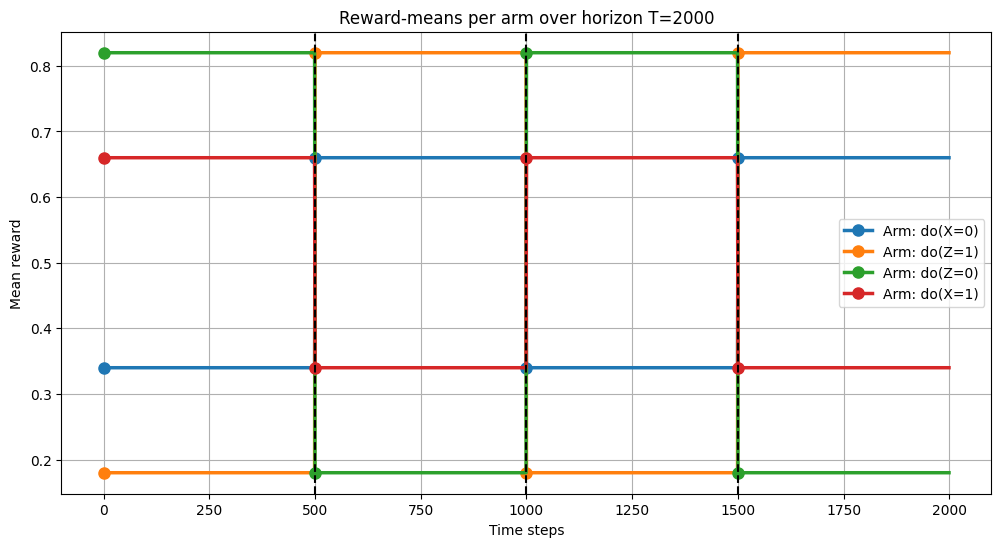

In [6]:
plot_historical_means(
    means_history=means_history,
    breakpoints=env.schedule.get_change_points(T=T),
    save_path=path / "historical_means.png"
)

### Dynamic regret

In [7]:
from cmab.metrics.base import BaseMetric

class DynamicRegret(BaseMetric):
    def __init__(self, T:int):
        self.T = T
        self.cumulative_regret = 0.0
        self.cumulative_regrets = np.zeros(T)
        self.step = 0

    def update(self, expected_reward: float, optimal_expected_reward: float) -> None:
        """Updates the cumulative regret with the received reward."""
        instant_regret = optimal_expected_reward - expected_reward
        self.cumulative_regret += instant_regret
        self.cumulative_regrets[self.step] = self.cumulative_regret
        self.step += 1
    
    def get_regrets(self) -> np.ndarray:
        """Returns the array of cumulative regrets recorded at each step."""
        return self.cumulative_regrets
    
    def get_regret_at_step(self, step:int) -> float:
        """Returns the cumulative regret at a specific step."""
        return self.cumulative_regrets[step]

    def reset(self) -> None:
        """Resets the cumulative regret metric."""
        self.cumulative_regret = 0.0
        self.cumulative_regrets = np.zeros(self.T)
        self.step = 0

### Running the agents

In [ ]:
regret = DynamicRegret(T=T)
agents = {"UCB": UCBAgent(reward_node=reward_node, arms=list(env.action_space), c=c), "SegmentUCB": SegmentUCBAgent(reward_node=reward_node, arms=list(env.action_space), c=c)}
averaged_regrets = {"UCB": np.zeros(T), "SegmentUCB": np.zeros(T)}
for agent_name, agent in agents.items():
    for i in range(n):
        if i % 10 == 0:
            print(f"  Run {i}/{n}")

        agent.reset()
        regret.reset()
        # Use a different seed for SCM for each run. Use same seed for NS to have same change points across agents
        # If you want different change points across runs, use SEED + i for ns_seed
        env.reset(scm_seed=seed+i, ns_seed=seed)
        for j in range(T):
            optimal_arm, opt_exp_reward = env.get_optimal()

            action = agent.select_arm()

            _, observation, _, _, _ = env.step(action)
            agent._update(action, observation)
            expected_reward = env.scm.expected_value(variable=reward_node, intervention=action)
            if agent_name == "UCB" and 500 <= j < 600:  # If _ is between 500 and 600, we are in the first 100 steps after the change point at 500, so print debug info
                print(f"Time step: {_}")
                print(f"Current UCB parameters:\n means: {agent.means} \n counts: {agent.arm_samples}")
                print(f"Computing regret between action {action} with expected reward {expected_reward} and optimal expected reward {opt_exp_reward} of optimal arm {optimal_arm}")
            regret.update(expected_reward, opt_exp_reward)
        
        averaged_regrets[agent_name] += regret.get_regrets() / n

  Run 0/10
Time step: {'steps': 501}
Current UCB parameters:
 means: [0.15789474 0.63157895 0.80978261 0.15789474] 
 counts: [ 19  95 368  19]
Computing regret between action frozenset({('Z', 0)}) with expected reward 0.18000000000000002 and optimal expected reward 0.8200000000000002 of optimal arm frozenset({('Z', 0)})
Time step: {'steps': 502}
Current UCB parameters:
 means: [0.15789474 0.63157895 0.80758808 0.15789474] 
 counts: [ 19  95 369  19]
Computing regret between action frozenset({('Z', 0)}) with expected reward 0.18000000000000002 and optimal expected reward 0.8200000000000002 of optimal arm frozenset({('Z', 1)})
Time step: {'steps': 503}
Current UCB parameters:
 means: [0.15789474 0.625      0.80758808 0.15789474] 
 counts: [ 19  96 369  19]
Computing regret between action frozenset({('X', 1)}) with expected reward 0.3400000000000001 and optimal expected reward 0.8200000000000002 of optimal arm frozenset({('Z', 1)})
Time step: {'steps': 504}
Current UCB parameters:
 means:

In [9]:
def plot_regrets_and_change_points(regrets, labels, title, change_points: list, T:int, save_path="plots/regret_curve_with_cps.png"):
    """Plots the averaged cumulative regrets along with vertical lines indicating change points.
    Args:
        regrets (list of np.ndarray): List of averaged cumulative regret arrays for each agent.
        labels (list of str): List of labels corresponding to each regret array.
        title (str): Title of the plot.
        change_points (list of int): List of time steps where change points occur.
    """
    for regret, label in zip(regrets, labels):
        plt.plot(regret, label=label)
    for t in range(1, T):
        if t in change_points:
            plt.axvline(x=t, color='red', linestyle='--', alpha=0.5)

    plt.xlabel("Time Steps")
    plt.ylabel("Averaged Cumulative Regret")
    plt.title(title)
    plt.legend()
    plt.show()


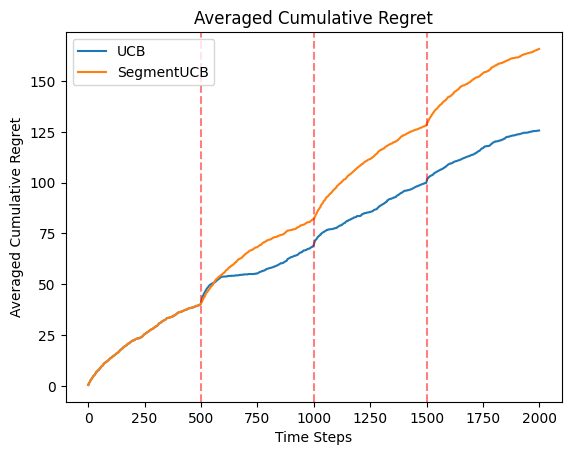

In [10]:
cps = env.schedule.get_change_points(T=T)

plot_regrets_and_change_points(
    regrets=averaged_regrets.values(),
    labels=averaged_regrets.keys(),
    title="Averaged Cumulative Regret",
    change_points=cps,
    T=T,
    save_path=path / "regret.png"
)